# Tree-based models

In this notebook, we train decision trees and Random Forests to classify graph nodes.

In [2]:
import torch
from torch_geometric.data import Data

elliptic = torch.load("../Dataset/processed/transaction_graph_v1.pt", weights_only=False, map_location="cpu")
txs_data = Data(**elliptic[0])
txs_data

Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])

## 1. Create strict time-forward split & select the labeled data

As observed in the EDA, the training, validation, and testing sets overlap across some time steps. We now create a clean time-forward split.


In [3]:
# Implement strict time-forward train/val/test split
# Training set: t = 1 - 34
# Validaton set: t = 35 - 41
# Testing set : t = 42 - 49

time_steps = txs_data.x[:,0]
new_train_mask = (time_steps >= 1) & (time_steps <= 32)
new_val_mask = (time_steps >= 33) & (time_steps <= 37)
new_test_mask = (time_steps >= 38) & (time_steps <= 42)

Also from our EDA, only 20% of data are labeled. We train our models based on these data. We also exlcude the first feature (time).

In [4]:
labeled = txs_data.y != 2

# Make the train/val/test sets, excluding the first feature (time)
X_train = txs_data.x[new_train_mask & labeled,1:].numpy()
X_val = txs_data.x[new_val_mask & labeled,1:].numpy()
X_test = txs_data.x[new_test_mask & labeled,1:].numpy()

y_train = txs_data.y[new_train_mask & labeled].numpy()
y_val = txs_data.y[new_val_mask & labeled].numpy()
y_test = txs_data.y[new_test_mask & labeled].numpy()

print("The size of the training set is:", len(X_train))
print("The size of the validation set is:", len(X_val))
print("The size of the testing set is:", len(X_test))

The size of the training set is: 28938
The size of the validation set is: 4503
The size of the testing set is: 6436


## 2. Feature scaling

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 3. Decision Tree

We implement a decision tree model. For hyperparameter tuning, we use average precision (as an estimate for PR-AUC) as the evaluation metric on the validation set.  

In [6]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import average_precision_score

params = {
    'max_depth': [3, 5, 7],
    'max_features':['sqrt', 0.3, 0.5, 0.7],
    'class_weight':[None, 'balanced']
}

best_param, best_val_ap = None, -np.inf

for param in ParameterGrid(params):
    tree_clf = DecisionTreeClassifier(**param, random_state=42)
    tree_clf.fit(X_train_scaled, y_train)

    y_val_scores = tree_clf.predict_proba(X_val_scaled)[:, 1]
    val_ap = average_precision_score(y_val, y_val_scores)

    if val_ap > best_val_ap:
        best_val_ap, best_params= val_ap, param

print("Best hyperparameters:", best_params)
print('Best average precison on the validation set', best_val_ap)


Best hyperparameters: {'class_weight': None, 'max_depth': 5, 'max_features': 0.5}
Best average precison on the validation set 0.8582906656950674


Now that we have determined the best set of hyperparameters, let's compare the average precision with PR-AUC computed using the trapezoidal rule. We also plot the precison-recall curve.

The average precison on the validation set: 0.8583
The PR-AUC on the validation set: 0.8852


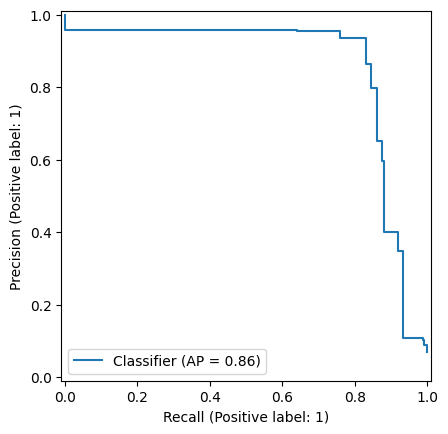

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, auc, PrecisionRecallDisplay

best_params = {'class_weight': None, 'max_depth': 5, 'max_features': 0.5}
tree_clf = DecisionTreeClassifier(**best_params, random_state = 42)
tree_clf.fit(X_train_scaled,y_train)

y_val_scores = tree_clf.predict_proba(X_val_scaled)[:,1]
precision, recall, thresholds = precision_recall_curve(y_val, y_val_scores)
pr_auc = auc(recall, precision)

PrecisionRecallDisplay.from_predictions(y_val, y_val_scores)

print(f"The average precison on the validation set: {best_val_ap:.4f}")
print(f"The PR-AUC on the validation set: {pr_auc:.4f}")

The area under the ROC curve is 0.9645.


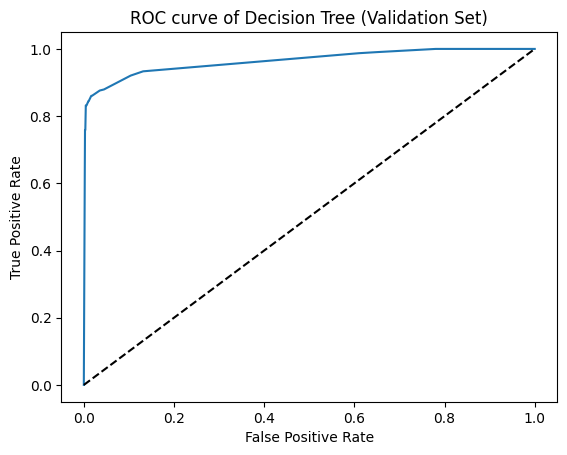

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_val, y_val_scores)
ft_auc = auc(fpr, tpr)
print(f"The area under the ROC curve is {ft_auc:.4f}.")

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of Decision Tree (Validation Set)')
plt.show()

Let's draw our decision tree.

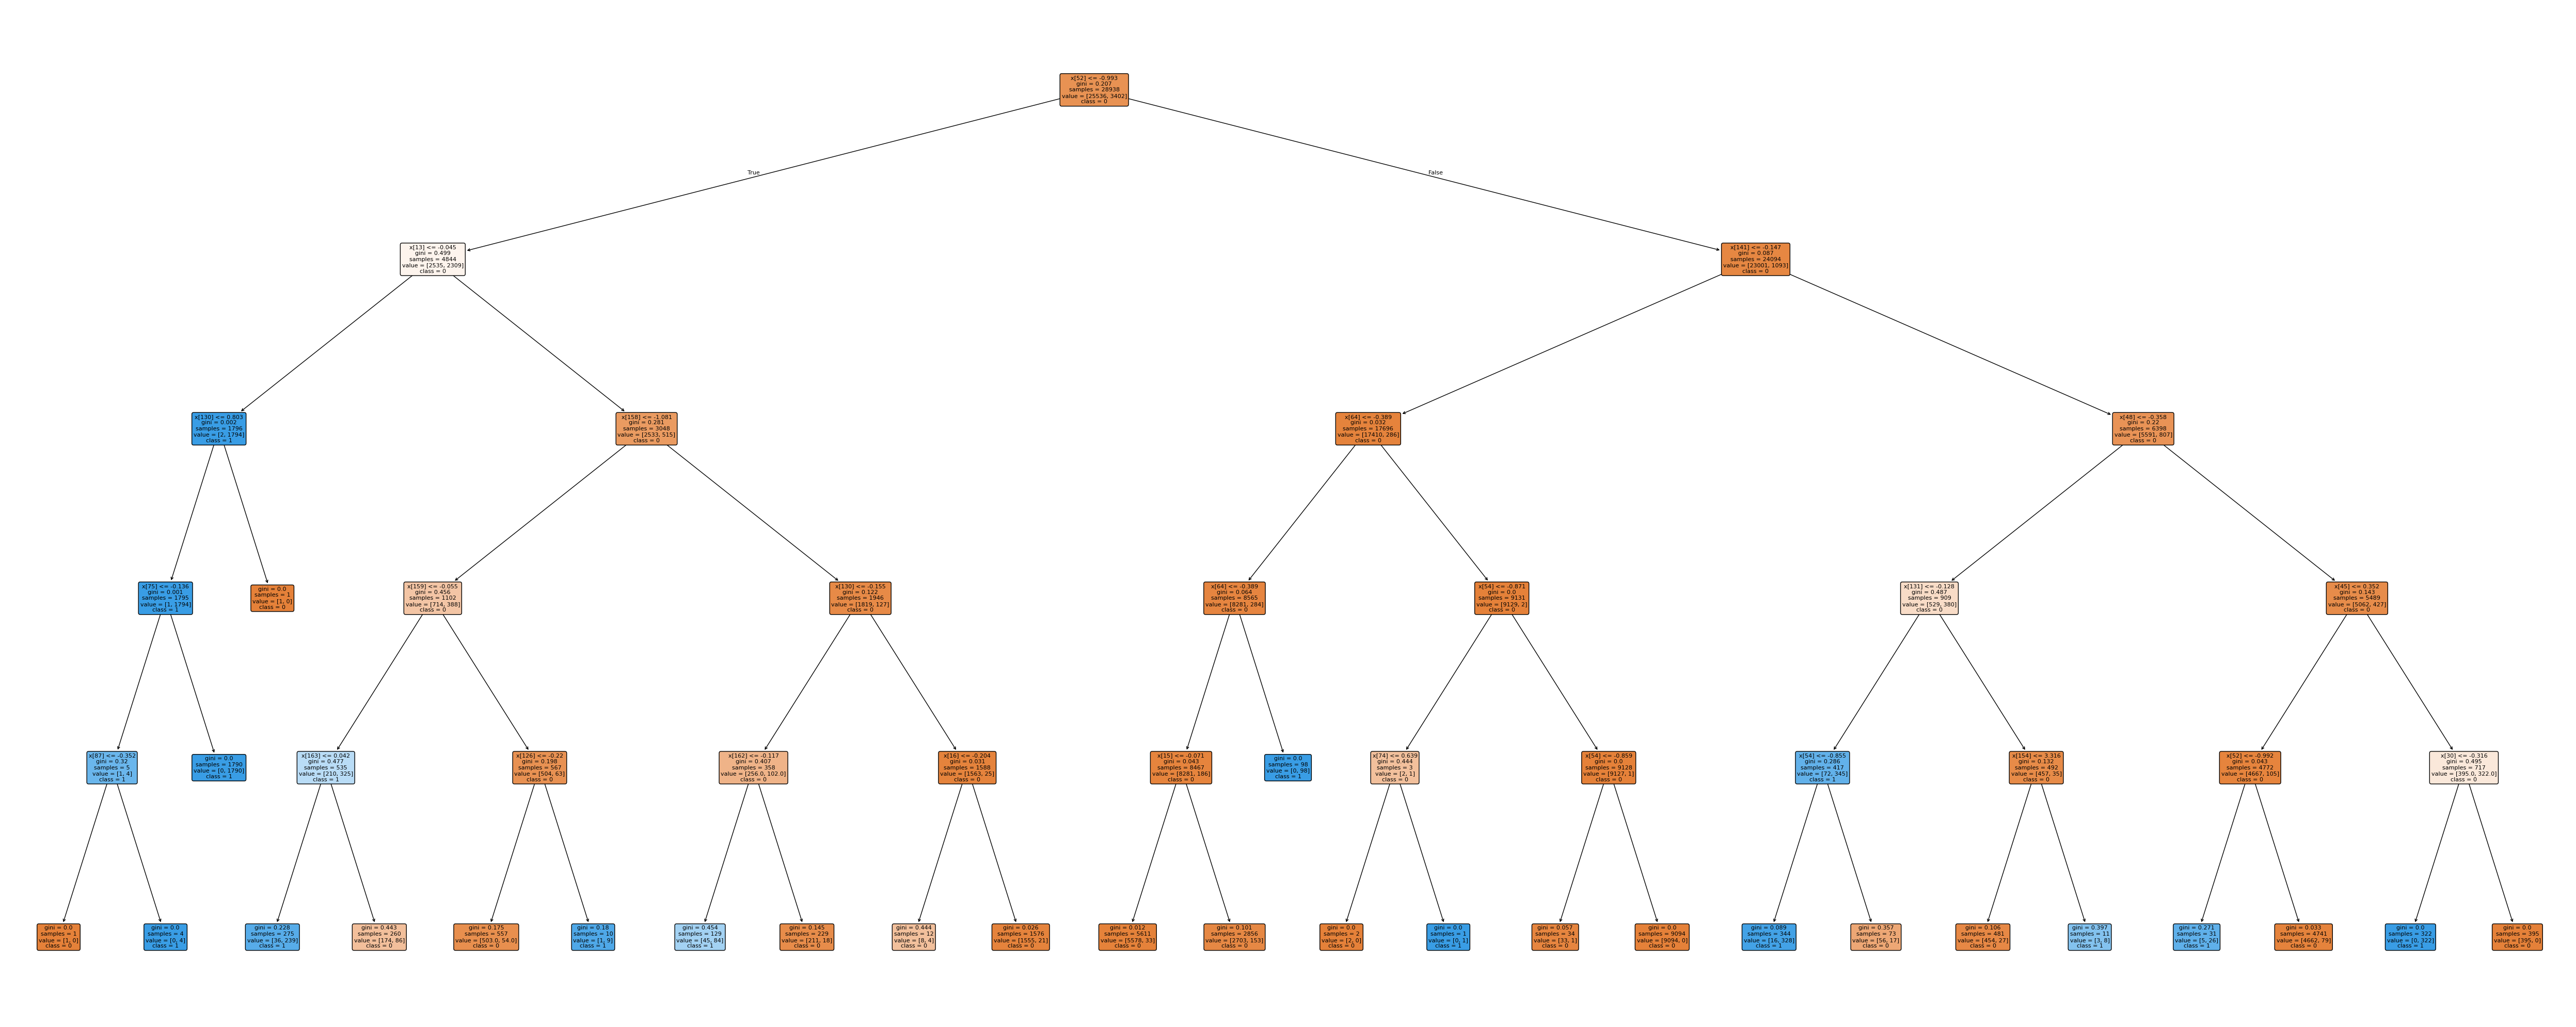

In [10]:
from sklearn.tree import plot_tree

# Draw the decision tree
plt.figure(figsize=(50, 20))
plot_tree(tree_clf, class_names=["0", "1"], filled=True, rounded=True, max_depth=5, fontsize=8)
plt.tight_layout()
plt.show()

For most leaf nodes, the Gini coefficients are sufficiently small. For leaf nodes with higher Gini coefficients, the number of samples are small. The leaf node with the largest sample is the last one, which contains 15259 samples (15203 licit and 56 ilicit) with Gini =  0.007.

## 4. Random Forest on all features

We now train a random forest model using all features. Previously, I trained the model using only the local features (the first 93 features), but its performance was worse. Hyperparameter tuning is time-consuming; therefore, we `n_estimators = 50`, following the choices in the original paper.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm

params = {
    'n_estimators': [50],
    'max_depth': [3, 5, 7],
    'max_features': ['sqrt', 0.3, 0.5],
    'class_weight': [None, 'balanced']
}

best_param, best_val_ap = None,-np.inf

grid = list(ParameterGrid(params))

for param in tqdm(grid, desc = 'Progress bar'):
  rf = RandomForestClassifier(**param, random_state=42, n_jobs=-1)
  rf.fit(X_train_scaled, y_train)

  y_val_scores = rf.predict_proba(X_val_scaled)[:,-1]
  val_ap = average_precision_score(y_val, y_val_scores)

  if val_ap > best_val_ap:
    best_param, best_val_ap = param, val_ap

print("The best param is", best_param)
print(f"The average precison on the validation set is {best_val_ap:.2f}")

Progress bar: 100%|██████████| 18/18 [00:18<00:00,  1.03s/it]

The best param is {'class_weight': None, 'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 50}
The average precison on the validation set is 0.95


The PR-AUC on the validation set is 0.9455
The average precision on the validation set is 0.9455 


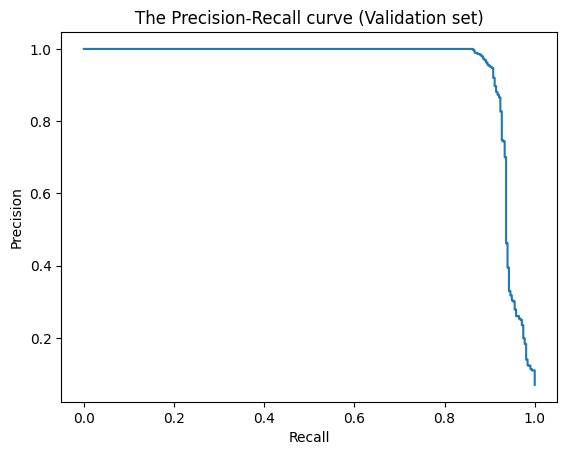

In [12]:
from sklearn.ensemble import RandomForestClassifier

best_param = {'class_weight': None, 'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 50}

rf = RandomForestClassifier(**best_param, random_state =42)
rf.fit(X_train_scaled, y_train)

y_val_scores = rf.predict_proba(X_val_scaled)[:,-1]
precision, recall, _ = precision_recall_curve(y_val, y_val_scores)
pr_auc = auc(recall, precision)

print(f"The PR-AUC on the validation set is {pr_auc:.4f}")
print(f"The average precision on the validation set is {best_val_ap:.4f} ")

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('The Precision-Recall curve (Validation set)')
plt.show()

The area under the ROC curve is 0.9804.


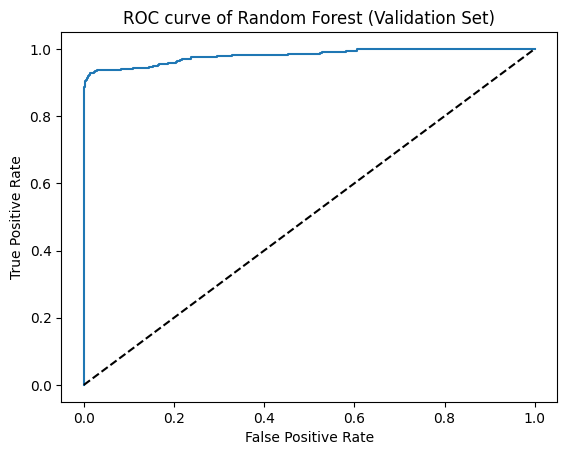

In [13]:
fpr, tpr, _ = roc_curve(y_val, y_val_scores)
ft_auc = auc(fpr, tpr)
print(f"The area under the ROC curve is {ft_auc:.4f}.")

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of Random Forest (Validation Set)')
plt.show()

As we can see, the random forest is slighly better than a single decison tree, achieving 0.92 PR-AUC on the validation set. Now, we retrain the model on both training and validation set and see how it performs on the testing set.

The PR-AUC on the testing set is 0.9012


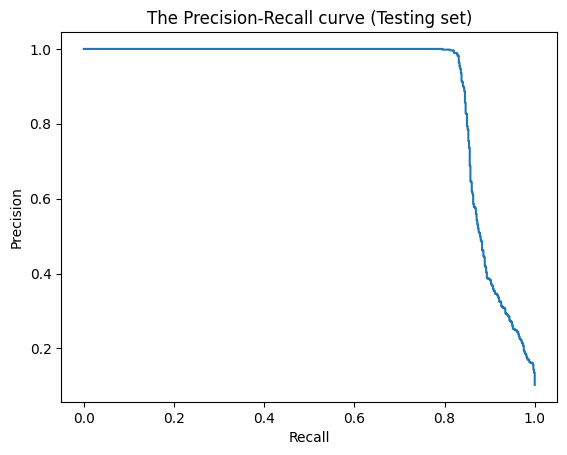

In [14]:
import numpy as np
from sklearn.metrics import precision_recall_curve, auc

X_train_val = np.vstack([X_train_scaled, X_val_scaled])
y_train_val = np.concatenate([y_train, y_val])


best_param = {'class_weight': None, 'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 50}

rf = RandomForestClassifier(**best_param, random_state =42)
rf.fit(X_train_val, y_train_val)

y_test_scores = rf.predict_proba(X_test_scaled)[:,-1]
precision, recall, thresholds = precision_recall_curve(y_test, y_test_scores)
pr_auc = auc(recall, precision)

print(f"The PR-AUC on the testing set is {pr_auc:.4f}")

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('The Precision-Recall curve (Testing set)')
plt.show()

We have precision = 1.0 until recall = 0.8, which means the model is extremely confident on the top 80% of the positive cases. Let's also look at the ROC curve on the testing set.

The area under the ROC curve is 0.96.


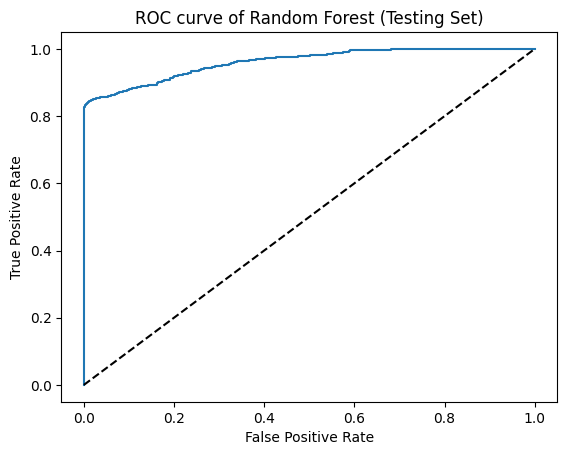

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
ft_auc = auc(fpr, tpr)
print(f"The area under the ROC curve is {ft_auc:.2f}.")

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of Random Forest (Testing Set)')
plt.show()